In [26]:
from hmm import HMMModel

# Load Data

Just use the test sequences

In [27]:
with open("data/phmm_train_motif1.fasta", "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f]
seqs = [lines[i] for i in range(len(lines)) if i % 2 == 1]

# Train Model

We are getting a good monotonic curve for the probability of the sequence

100%|██████████| 4/4 [00:00<?, ?it/s]


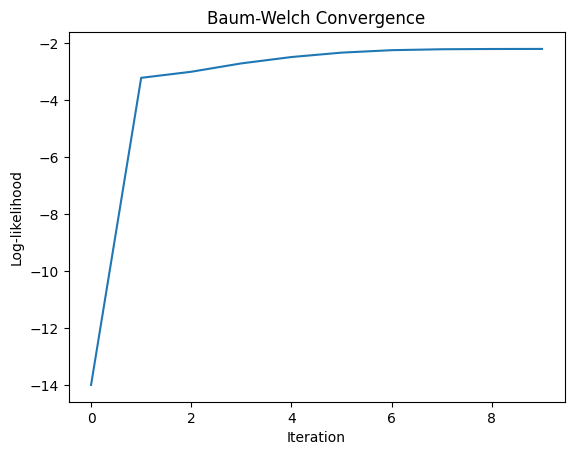

In [28]:
hmm = HMMModel()
hmm.random_initialise_phmm(sequence_length=[len(seq) for seq in seqs])
hmm.baum_welch_profile(seqs=seqs, convergence_threshold= 0, max_iter=10)

# Test with Viterbi

Our algorithm heavily favories insertion states, which might be a consequence of uniform initialization of insertion emissions

In [29]:
test_seq = seqs[2]
print(test_seq)
vmat, tmat, path = hmm.viterbi_profile(test_seq)
print(path)

VE--D
['I', 'M', 'D', 'D', 'M']


# Now with MSA initialization

In [30]:
hmm2 = HMMModel()
hmm2.init_msa(seqs)

print(test_seq)
vmat, tmat, path = hmm2.viterbi_profile(test_seq)
print(path)

VE--D
['M', 'M', 'D', 'D', 'M']
